# Createur procedural d'environnements avec agent RL

## Concept
- Un **generateur** cree des labyrinthes sous forme de matrices textuelles
- Un **agent RL** (Q-Learning) tente de resoudre chaque labyrinthe
- Le generateur est **recompense** s'il produit un niveau *faisable mais challengeant*

Symboles : `S`=depart, `E`=sortie, `#`=mur, `.`=libre

## Parametres du projet

Modifiez cette cellule pour configurer l'experience.

In [200]:
# ==================================================================
# PARAMETRES DU PROJET
# Modifiez ces valeurs pour configurer le labyrinthe et l'entrainement
# ==================================================================

# --- Labyrinthe ---
MAZE_HEIGHT = 32       # Hauteur du labyrinthe (nombre de lignes)
MAZE_WIDTH  = 32       # Largeur du labyrinthe (nombre de colonnes)

# Position du point d'arrivee E (indices dans la grille)
# CONTRAINTE : valeurs IMPAIRES dans [1, dim-2]
#   Pour une grille 16x16 : valeurs valides = 1, 3, 5, 7, 9, 11, 13
#   Mettre None = coin bas-droite atteignable (defaut)
MAZE_END_ROW = None    # Ligne de E   (ex: 13 pour bas,  1 pour haut)
MAZE_END_COL = None    # Colonne de E (ex: 13 pour droite, 1 pour gauche)

# --- Entrainement ---
N_LEVELS           = 100   # Nombre de labyrinthes generes
EPISODES_PER_LEVEL = 1000  # Episodes d'entrainement par labyrinthe
VERBOSE_EVERY      = 10    # Afficher les stats toutes les N niveaux

# --- Agent Q-Learning ---
AGENT_LR            = 0.1   # Taux d'apprentissage de l'agent
AGENT_GAMMA         = 0.95  # Facteur de discount (importance du futur)
AGENT_EPSILON       = 1.0   # Taux d'exploration initial (1.0 = 100% aleatoire)
AGENT_EPSILON_DECAY = 0.995 # Decroissance de l'exploration a chaque episode
AGENT_EPSILON_MIN   = 0.05  # Taux d'exploration minimal

# --- Generateur neuronal ---
# Le reseau de neurones joue le role de politique DFS :
#   a chaque etape du DFS, il choisit quelle direction explorer.
# Entraine par REINFORCE (policy gradient) avec baseline EWMA.
GENERATOR_LR           = 1e-3   # Taux d'apprentissage de l'optimiseur Adam
GENERATOR_HIDDEN       = 64     # Taille des couches cachees du reseau
GENERATOR_ENTROPY_COEF = 0.01   # Coefficient de regularisation entropique

# --- Reproductibilite ---
RANDOM_SEED = 42

# --- Calcul automatique de la position de E ---
def _compute_end_pos(height, width, end_row, end_col):
    max_r = 1 + 2 * ((height - 3) // 2)
    max_c = 1 + 2 * ((width  - 3) // 2)
    r = end_row if end_row is not None else max_r
    c = end_col if end_col is not None else max_c
    r = max(1, min(r, max_r))
    c = max(1, min(c, max_c))
    if r % 2 == 0: r -= 1
    if c % 2 == 0: c -= 1
    return (r, c)

MAZE_END_POS = _compute_end_pos(MAZE_HEIGHT, MAZE_WIDTH, MAZE_END_ROW, MAZE_END_COL)

print('Parametres charges :')
print(f'  Labyrinthe   : {MAZE_HEIGHT}x{MAZE_WIDTH}')
print(f'  S=(1,1)  E={MAZE_END_POS}')
print(f'  Generateur   : lr={GENERATOR_LR}  hidden={GENERATOR_HIDDEN}  entropy_coef={GENERATOR_ENTROPY_COEF}')
print(f'  Entrainement : {N_LEVELS} niveaux x {EPISODES_PER_LEVEL} episodes')
print(f'  Agent        : lr={AGENT_LR}  gamma={AGENT_GAMMA}  eps_decay={AGENT_EPSILON_DECAY}')


Parametres charges :
  Labyrinthe   : 32x32
  S=(1,1)  E=(29, 29)
  Generateur   : lr=0.001  hidden=64  entropy_coef=0.01
  Entrainement : 100 niveaux x 1000 episodes
  Agent        : lr=0.1  gamma=0.95  eps_decay=0.995


## 1. Imports

In [201]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical
import warnings
warnings.filterwarnings('ignore')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print('Imports OK')


Imports OK


## 2. L'environnement Labyrinthe (`MazeEnv`)

Represente un labyrinthe. L'agent s'y deplace case par case.
A chaque pas : `step(action)` retourne `(nouvel_etat, recompense, termine)`.

In [202]:
class MazeEnv:
    '''
    Environnement labyrinthe pour l'agent RL.
    Grille textuelle : S=depart  E=sortie  #=mur  .=libre

    Recompenses :
      +100  quand l'agent atteint E
       -10  si l'agent depasse max_steps (timeout)
       -0.1 a chaque pas normal (encourage les chemins courts)
    '''
    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # haut, bas, gauche, droite

    def __init__(self, grid):
        self.grid   = [list(row) for row in grid]
        self.height = len(self.grid)
        self.width  = len(self.grid[0])
        self.start  = self._find('S')
        self.end    = self._find('E')
        self.agent_pos = self.start
        self.steps     = 0
        self.max_steps = self.height * self.width * 2

    def _find(self, symbol):
        for r in range(self.height):
            for c in range(self.width):
                if self.grid[r][c] == symbol:
                    return (r, c)
        return None

    def reset(self):
        self.agent_pos = self.start
        self.steps = 0
        return self.agent_pos

    def step(self, action):
        self.steps += 1
        dr, dc = self.ACTIONS[action]
        r, c   = self.agent_pos
        nr, nc = r + dr, c + dc

        # Mouvement valide = dans la grille ET pas un mur
        if (0 <= nr < self.height and 0 <= nc < self.width
                and self.grid[nr][nc] != '#'):
            self.agent_pos = (nr, nc)

        if self.agent_pos == self.end:
            return self.agent_pos, 100.0, True    # victoire
        elif self.steps >= self.max_steps:
            return self.agent_pos, -10.0, True    # timeout
        else:
            return self.agent_pos, -0.1,  False   # pas normal

    def render(self, ax=None):
        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=(self.width * 0.7, self.height * 0.7))
        color_map = {'#': 'black', '.': 'white', 'S': 'green', 'E': 'red'}
        for r in range(self.height):
            for c in range(self.width):
                cell = self.grid[r][c]
                rect = mpatches.FancyBboxPatch(
                    (c, self.height - r - 1), 1, 1,
                    boxstyle='square,pad=0',
                    facecolor=color_map.get(cell, 'white'),
                    edgecolor='gray', linewidth=0.5)
                ax.add_patch(rect)
                if cell in ('S', 'E'):
                    ax.text(c + 0.5, self.height - r - 0.5, cell,
                            ha='center', va='center',
                            color='white', fontweight='bold', fontsize=10)
        ar, ac = self.agent_pos
        ax.plot(ac + 0.5, self.height - ar - 0.5, 'bo', markersize=10)
        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect('equal')
        ax.axis('off')
        if show:
            plt.tight_layout()
            plt.show()

print('Classe MazeEnv definie')

Classe MazeEnv definie


## 3. Le Generateur Procedural (`MazeGenerator`)

Les cases de **bordure sont toujours des murs** (`#`).
Le generateur utilise le **DFS guide par un reseau de neurones** entraine
par REINFORCE (policy gradient).

### Architecture de la politique DFS

A chaque pas du DFS, le reseau recoit **14 features** et produit une distribution
sur les 4 directions, masquee sur les directions invalides.

| Groupe | Features | Taille |
|---|---|---|
| Position courante normalisee | r/H, c/W | 2 |
| Position de E normalisee | er/H, ec/W | 2 |
| Profondeur de la pile | stack\_depth / aire | 1 |
| Cellules visitees | n\_visited / aire | 1 |
| Par direction (x4) | valide + dist\_to\_E normalisee | 8 |
| **Total** | | **14** |

### Algorithme REINFORCE

```
Pour chaque labyrinthe genere :
  1. DFS : a chaque choix, echantillonner une direction via le reseau
     -> enregistrer log_prob et entropie de chaque decision
  2. Recevoir la recompense R apres evaluation par l'agent
  3. Avantage = R - baseline  (baseline = EWMA des recompenses passees)
  4. Loss = -avantage * mean(log_probs) - entropy_coef * mean(entropies)
  5. Retropropagation + Adam
```

### Logique de recompense

```
recompense = solve_rate x (avg_steps / max_steps)
```

| Composante | Signification |
|---|---|
| `solve_rate` | Fraction des episodes ou l'agent a resolu (doit resoudre !) |
| `avg_steps` | Nombre moyen de pas sur les episodes resolus (doit etre long !) |


In [203]:
class DFSPolicyNet(nn.Module):
    '''
    Reseau de neurones : politique pour le DFS du generateur.
    Input  : 14 features (position, profondeur, directions valides + distances)
    Output : 4 logits (une par direction cardinale)
    '''
    def __init__(self, hidden=GENERATOR_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(14, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4),
        )

    def forward(self, x):
        return self.net(x)


class MazeGenerator:
    '''
    Generateur procedural de labyrinthes via DFS guide par une politique NN.

    A chaque etape du DFS, le reseau choisit quelle direction explorer parmi
    les voisins valides (non visites, dans les bornes).
    Entraine par REINFORCE avec baseline EWMA.

    Recompense : solve_rate * (avg_steps / max_steps)
    '''

    DIRECTIONS = [(0, 2), (0, -2), (2, 0), (-2, 0)]   # droite, gauche, bas, haut

    def __init__(self, height=MAZE_HEIGHT, width=MAZE_WIDTH,
                 end_pos=MAZE_END_POS,
                 learning_rate=GENERATOR_LR,
                 hidden=GENERATOR_HIDDEN,
                 entropy_coef=GENERATOR_ENTROPY_COEF):

        self.height       = height
        self.width        = width
        self.end_pos      = end_pos
        self.start_pos    = (1, 1)
        self.entropy_coef = entropy_coef

        # Nombre de "rooms" DFS (cellules visitables = positions impaires)
        self.n_interior = ((height - 2) // 2) * ((width - 2) // 2)

        # Reseau de politique + optimiseur Adam
        self.policy_net = DFSPolicyNet(hidden=hidden)
        self.optimizer  = torch.optim.Adam(
            self.policy_net.parameters(), lr=learning_rate)

        # Trajectoire de l'episode courant (reinitialise a chaque generate())
        self._log_probs = []
        self._entropies = []

        # Baseline EWMA pour reduire la variance de REINFORCE
        self.baseline       = 0.0
        self.baseline_alpha = 0.05   # lissage lent -> baseline stable

        # Historiques pour la visualisation
        self.reward_history = []
        self.loss_history   = []

        n_params = sum(p.numel() for p in self.policy_net.parameters())
        print(f'  Labyrinthe    : {height}x{width}')
        print(f'  S={self.start_pos}  E={self.end_pos}')
        print(f'  NN generateur : hidden={hidden}  params={n_params}  lr={learning_rate}')

    # ------------------------------------------------------------------
    # Construction des features (14-dim)
    # ------------------------------------------------------------------

    def _build_features(self, r, c, stack_depth, n_visited, valid_neighbors):
        '''
        Construit le vecteur de 14 features normalises :
          [r/H, c/W, er/H, ec/W, depth/area, visited/area,
           valid_0, dist_0, valid_1, dist_1, valid_2, dist_2, valid_3, dist_3]

        valid_neighbors : liste de 4 entrees dans l'ordre DIRECTIONS
          chaque entree est (nr, nc, wr, wc) ou None si direction invalide
        '''
        er, ec   = self.end_pos
        H, W     = float(self.height), float(self.width)
        area     = float(max(self.n_interior, 1))
        max_dist = H + W

        feats = [
            r / H,
            c / W,
            er / H,
            ec / W,
            min(stack_depth / area, 1.0),
            min(n_visited   / area, 1.0),
        ]

        for entry in valid_neighbors:
            if entry is None:
                feats.extend([0.0, 0.0])
            else:
                nr, nc = entry[0], entry[1]
                dist_norm = (abs(nr - er) + abs(nc - ec)) / max_dist
                feats.extend([1.0, dist_norm])

        return torch.tensor(feats, dtype=torch.float32)

    # ------------------------------------------------------------------
    # Generation
    # ------------------------------------------------------------------

    def generate(self):
        '''Genere un labyrinthe via DFS guide par le reseau de politique.'''
        self._log_probs = []
        self._entropies = []
        return self._create_dfs_maze()

    def _create_dfs_maze(self):
        '''
        DFS avec choix de direction par le reseau de neurones.
        Les log_probs et entropies sont accumules pour REINFORCE.
        '''
        grid = [['#'] * self.width for _ in range(self.height)]
        sr, sc = self.start_pos
        er, ec = self.end_pos

        visited = {(sr, sc)}
        stack   = [(sr, sc)]
        grid[sr][sc] = '.'

        while stack:
            r, c = stack[-1]

            # Construire valid_neighbors (ordre fixe = DIRECTIONS)
            valid_neighbors = []
            any_valid = False
            for dr, dc in self.DIRECTIONS:
                nr, nc = r + dr, c + dc
                if (1 <= nr <= self.height - 2 and
                    1 <= nc <= self.width  - 2 and
                    (nr, nc) not in visited):
                    valid_neighbors.append((nr, nc, r + dr // 2, c + dc // 2))
                    any_valid = True
                else:
                    valid_neighbors.append(None)

            if any_valid:
                # Calcul des features et appel au reseau
                feats  = self._build_features(
                    r, c, len(stack), len(visited), valid_neighbors)
                logits = self.policy_net(feats)

                # Masque -inf sur les directions invalides
                mask = torch.tensor(
                    [0.0 if v is not None else float('-inf')
                     for v in valid_neighbors])
                dist_cat = Categorical(logits=logits + mask)
                action   = dist_cat.sample()

                self._log_probs.append(dist_cat.log_prob(action))
                self._entropies.append(dist_cat.entropy())

                nr, nc, wr, wc = valid_neighbors[action.item()]
                grid[wr][wc] = '.'
                grid[nr][nc] = '.'
                visited.add((nr, nc))
                stack.append((nr, nc))
            else:
                stack.pop()

        grid[sr][sc] = 'S'
        grid[er][ec] = 'E'
        return [''.join(row) for row in grid]

    # ------------------------------------------------------------------
    # Chemin optimal (BFS)
    # ------------------------------------------------------------------

    def shortest_path(self, grid):
        '''BFS : retourne la longueur du chemin optimal de S vers E.'''
        start = end = None
        for r, row in enumerate(grid):
            for c, cell in enumerate(row):
                if cell == 'S': start = (r, c)
                elif cell == 'E': end = (r, c)
        queue, visited = deque([(start, 0)]), {start}
        while queue:
            (r, c), dist = queue.popleft()
            if (r, c) == end:
                return dist
            for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nr, nc = r+dr, c+dc
                if (0 <= nr < len(grid) and 0 <= nc < len(grid[0])
                        and (nr, nc) not in visited
                        and grid[nr][nc] != '#'):
                    visited.add((nr, nc))
                    queue.append(((nr, nc), dist+1))
        return float('inf')

    # ------------------------------------------------------------------
    # Signal de recompense
    # ------------------------------------------------------------------

    def compute_generator_reward(self, solve_rate, avg_steps):
        '''
        recompense = solve_rate * (avg_steps / max_steps)
        Retourne 0.0 si solve_rate < 5% (labyrinthe infranchissable).
        '''
        if solve_rate < 0.05:
            return 0.0
        max_steps = self.height * self.width * 2
        score_pas = min(1.0, avg_steps / max_steps)
        return solve_rate * score_pas

    # ------------------------------------------------------------------
    # Mise a jour REINFORCE
    # ------------------------------------------------------------------

    def update(self, solve_rate, generator_reward):
        '''
        REINFORCE avec baseline EWMA :
          advantage = generator_reward - baseline
          loss = -advantage * mean(log_probs) - entropy_coef * mean(entropies)
        '''
        self.reward_history.append(generator_reward)

        if not self._log_probs:
            self.loss_history.append(0.0)
            return

        # Mise a jour de la baseline EWMA
        self.baseline = ((1 - self.baseline_alpha) * self.baseline
                         + self.baseline_alpha * generator_reward)
        advantage = generator_reward - self.baseline

        log_probs_t = torch.stack(self._log_probs)
        entropies_t = torch.stack(self._entropies)

        loss = (-advantage * log_probs_t.mean()
                - self.entropy_coef * entropies_t.mean())

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        self.loss_history.append(loss.item())
        self._log_probs = []
        self._entropies = []

print('Classes DFSPolicyNet et MazeGenerator definies')


Classes DFSPolicyNet et MazeGenerator definies


## 4. L'Agent RL (`QLearningAgent`)

Apprend a naviguer dans les labyrinthes via **Q-Learning** :
- **Table Q** : pour chaque case `(r, c)`, stocke la valeur de chaque action
- **Mise a jour Bellman** : `Q(s,a) <- Q(s,a) + lr * (r + gamma*max Q(s') - Q(s,a))`
- **Politique epsilon-greedy** : explore aleatoirement avec probabilite epsilon, sinon exploite la meilleure action

In [204]:
class QLearningAgent:
    '''
    Agent Q-Learning tabulaire.
    q_table : dict { (ligne, colonne) -> array de 4 valeurs (une par action) }
    '''

    def __init__(self,
                 n_actions=4,
                 lr=AGENT_LR,
                 gamma=AGENT_GAMMA,
                 epsilon=AGENT_EPSILON,
                 epsilon_decay=AGENT_EPSILON_DECAY,
                 epsilon_min=AGENT_EPSILON_MIN):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.q_table       = {}  # initialise a la premiere visite de chaque case

    def _get_q(self, state):
        '''Retourne les valeurs Q de l'etat (cree l'entree si inexistante).'''
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]

    def choose_action(self, state):
        '''Politique epsilon-greedy.'''
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)  # exploration
        return int(np.argmax(self._get_q(state)))          # exploitation

    def update(self, state, action, reward, next_state, done):
        '''Mise a jour de la table Q via la formule de Bellman.'''
        target = reward if done else reward + self.gamma * np.max(self._get_q(next_state))
        self._get_q(state)[action] += self.lr * (target - self._get_q(state)[action])

    def run_episode(self, env):
        '''
        Joue un episode complet.
        Retourne (resolu: bool, nombre_de_pas: int)
        '''
        state = env.reset()
        while True:
            action = self.choose_action(state)
            next_state, reward, done = env.step(action)
            self.update(state, action, reward, next_state, done)
            state = next_state
            if done:
                solved = (state == env.end)
                self.epsilon = max(self.epsilon_min,
                                   self.epsilon * self.epsilon_decay)
                return solved, env.steps

print('Classe QLearningAgent definie')

Classe QLearningAgent definie


## 5. Boucle d'entrainement

A chaque niveau :
1. Le generateur cree un labyrinthe
2. L'agent s'entraine dessus (`EPISODES_PER_LEVEL` fois)
3. On mesure ses performances (taux de reussite, nombre de pas)
4. Le generateur recoit une recompense et ajuste `wall_prob`

In [205]:
def train(n_levels=N_LEVELS,
          episodes_per_level=EPISODES_PER_LEVEL,
          maze_height=MAZE_HEIGHT,
          maze_width=MAZE_WIDTH,
          verbose_every=VERBOSE_EVERY):
    '''
    Boucle principale : generation -> entrainement agent -> feedback -> mise a jour generateur.
    '''
    generator = MazeGenerator(height=maze_height, width=maze_width)
    agent     = QLearningAgent()

    history = {'level': [], 'gen_reward': [], 'solve_rate': [],
               'avg_steps': [], 'loss': []}

    print(f'Entrainement : {n_levels} niveaux x {episodes_per_level} episodes')
    print('-' * 72)

    for level_idx in range(n_levels):

        # 1. Generer un labyrinthe
        grid = generator.generate()
        env  = MazeEnv(grid)

        # 2. Entrainer l'agent sur ce labyrinthe
        solve_count = 0
        total_steps = 0

        for _ in range(episodes_per_level):
            solved, steps = agent.run_episode(env)
            if solved:
                solve_count += 1
                total_steps += steps

        solve_rate = solve_count / episodes_per_level
        avg_steps  = total_steps / max(solve_count, 1)

        # 3. Recompense du generateur : solve_rate * (avg_steps / max_steps)
        gen_reward = generator.compute_generator_reward(solve_rate, avg_steps)

        # 4. Mise a jour du generateur (REINFORCE)
        generator.update(solve_rate, gen_reward)

        current_loss = generator.loss_history[-1] if generator.loss_history else 0.0
        history['level'].append(level_idx + 1)
        history['gen_reward'].append(gen_reward)
        history['solve_rate'].append(solve_rate)
        history['avg_steps'].append(avg_steps)
        history['loss'].append(current_loss)

        if (level_idx + 1) % verbose_every == 0:
            print(f'Niveau {level_idx+1:3d} | '
                  f'Resolution: {solve_rate:.0%} | '
                  f'Moy. pas: {avg_steps:6.1f} | '
                  f'Recomp. gene: {gen_reward:.3f} | '
                  f'loss NN: {current_loss:+.4f}')

    print('-' * 72)
    final_loss = generator.loss_history[-1] if generator.loss_history else 0.0
    print(f'Termine ! Epsilon agent: {agent.epsilon:.3f} | '
          f'baseline: {generator.baseline:.4f} | '
          f'loss NN finale: {final_loss:+.4f}')
    return generator, agent, history

print('Fonction train() definie')


Fonction train() definie


## 6. Lancement de l'entrainement

Utilise les parametres definis dans la cellule **Parametres** en haut.

In [206]:
generator, agent, history = train(
    n_levels           = N_LEVELS,
    episodes_per_level = EPISODES_PER_LEVEL,
    maze_height        = MAZE_HEIGHT,
    maze_width         = MAZE_WIDTH,
    verbose_every      = VERBOSE_EVERY,
)

  Labyrinthe    : 32x32
  S=(1, 1)  E=(29, 29)
  NN generateur : hidden=64  params=5380  lr=0.001
Entrainement : 100 niveaux x 1000 episodes
------------------------------------------------------------------------
Niveau  10 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0059
Niveau  20 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0061
Niveau  30 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0058
Niveau  40 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0060
Niveau  50 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0060
Niveau  60 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0060
Niveau  70 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0059
Niveau  80 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0.0059
Niveau  90 | Resolution: 0% | Moy. pas:    0.0 | Recomp. gene: 0.000 | loss NN: -0

## 7. Visualisation des resultats

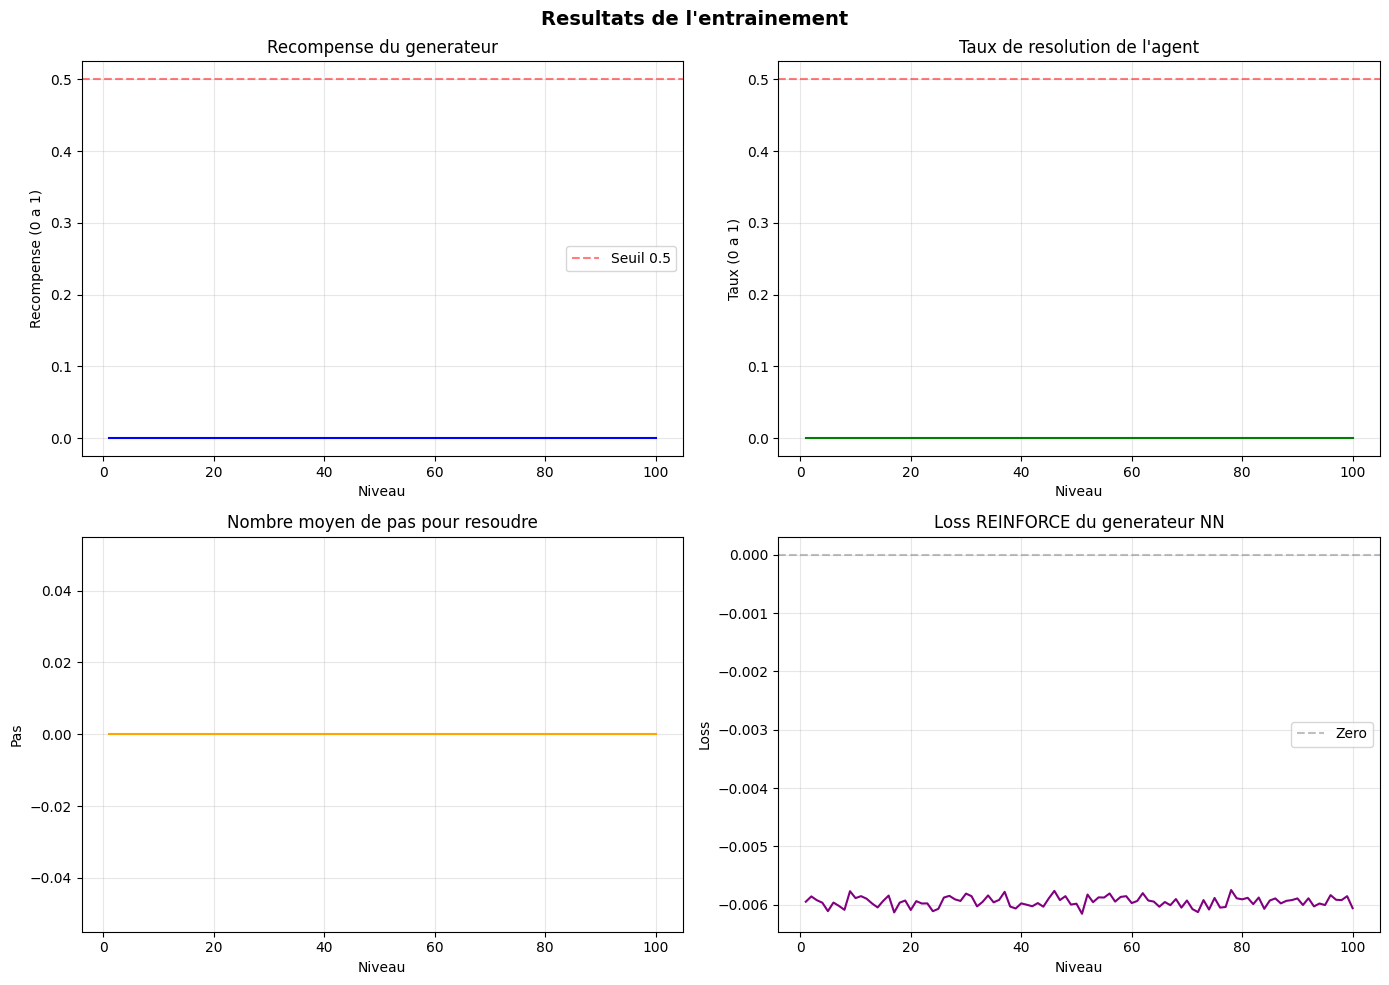

In [207]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Resultats de l'entrainement", fontsize=14, fontweight='bold')
levels = history['level']

# 1. Recompense du generateur
axes[0,0].plot(levels, history['gen_reward'], color='blue', linewidth=1.5)
axes[0,0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil 0.5')
axes[0,0].set_title('Recompense du generateur')
axes[0,0].set_xlabel('Niveau')
axes[0,0].set_ylabel('Recompense (0 a 1)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Taux de resolution
axes[0,1].plot(levels, history['solve_rate'], color='green', linewidth=1.5)
axes[0,1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_title("Taux de resolution de l'agent")
axes[0,1].set_xlabel('Niveau')
axes[0,1].set_ylabel('Taux (0 a 1)')
axes[0,1].grid(True, alpha=0.3)

# 3. Nombre moyen de pas
axes[1,0].plot(levels, history['avg_steps'], color='orange', linewidth=1.5)
axes[1,0].set_title('Nombre moyen de pas pour resoudre')
axes[1,0].set_xlabel('Niveau')
axes[1,0].set_ylabel('Pas')
axes[1,0].grid(True, alpha=0.3)

# 4. Loss REINFORCE du generateur NN
axes[1,1].plot(levels, history['loss'], color='purple', linewidth=1.5)
axes[1,1].axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Zero')
axes[1,1].set_title('Loss REINFORCE du generateur NN')
axes[1,1].set_xlabel('Niveau')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Demonstration finale

Genere 3 labyrinthes avec le generateur entraine et affiche les performances de l'agent.

Baseline EWMA finale : 0.0000

Labyrinthe 1
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 172 | Ratio : 11.91x
  Recompense generateur : 0.00

Labyrinthe 2
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 200 | Ratio : 10.24x
  Recompense generateur : 0.00

Labyrinthe 3
  Resolu    : NON
  Pas pris  : 2048 | Optimal : 224 | Ratio : 9.14x
  Recompense generateur : 0.00


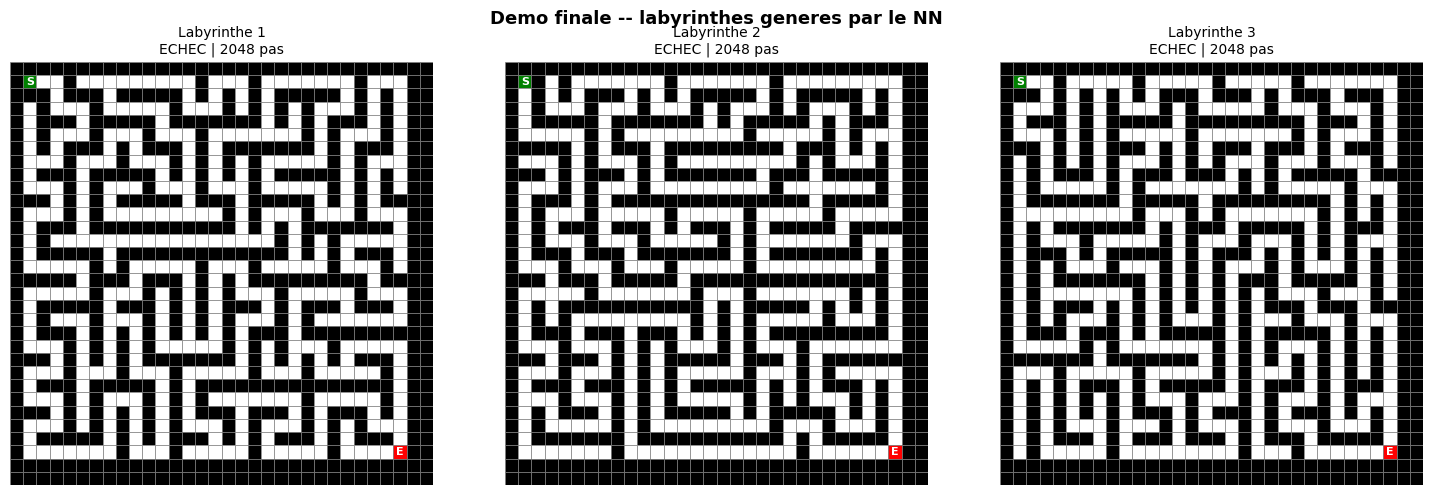

In [208]:
agent.epsilon = 0.0  # mode exploitation pure (plus d'exploration aleatoire)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Demo finale -- labyrinthes generes par le NN', fontsize=13, fontweight='bold')

print(f'Baseline EWMA finale : {generator.baseline:.4f}')
print('=' * 55)

for i in range(3):
    with torch.no_grad():
        grid = generator.generate()
    env    = MazeEnv(grid)
    solved, steps = agent.run_episode(env)
    optimal    = generator.shortest_path(grid)
    solve_rate = 1.0 if solved else 0.0
    gen_reward = generator.compute_generator_reward(solve_rate, steps)

    print(f'\nLabyrinthe {i+1}')
    if MAZE_HEIGHT <= 12 and MAZE_WIDTH <= 12:
        for row in grid:
            print('  ' + row)
    print(f'  Resolu    : {"OUI" if solved else "NON"}')
    if optimal != float('inf'):
        print(f'  Pas pris  : {steps} | Optimal : {optimal} | Ratio : {steps/optimal:.2f}x')
    print(f'  Recompense generateur : {gen_reward:.2f}')

    ax = axes[i]
    color_map = {'#': 'black', '.': 'white', 'S': 'green', 'E': 'red'}
    h, w = env.height, env.width
    for r in range(h):
        for c in range(w):
            cell = env.grid[r][c]
            rect = mpatches.FancyBboxPatch(
                (c, h-r-1), 1, 1, boxstyle='square,pad=0',
                facecolor=color_map.get(cell, 'white'),
                edgecolor='gray', linewidth=0.5)
            ax.add_patch(rect)
            if cell in ('S', 'E'):
                ax.text(c+0.5, h-r-0.5, cell, ha='center', va='center',
                        color='white', fontweight='bold', fontsize=8)
    status = f'{"RESOLU" if solved else "ECHEC"} | {steps} pas'
    ax.set_title(f'Labyrinthe {i+1}\n{status}', fontsize=10)
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()


## 9. Resume du projet

### Architecture

| Composant | Role |
|---|---|
| **MazeEnv** | Environnement RL (grille, deplacements, recompenses) |
| **MazeGenerator** | Genere des labyrinthes, apprend a ajuster la densite de murs |
| **QLearningAgent** | Apprend a resoudre les labyrinthes via Q-Learning |
| **train()** | Boucle qui fait cooperer les deux composants |

### Guide des parametres

| Parametre | Effet |
|---|---|
| `MAZE_HEIGHT / MAZE_WIDTH` | Taille du labyrinthe (plus grand = plus lent) |
| `WALL_PROB_INIT` | Densite de murs de depart (0.1 = peu de murs, 0.5 = dense) |
| `WALL_PROB_MIN / MAX` | Bornes : le generateur ne sort jamais de cet intervalle |
| `N_LEVELS` | Nombre de labyrinthes generes au total |
| `EPISODES_PER_LEVEL` | Temps d'entrainement par labyrinthe (plus = meilleur agent) |
| `AGENT_LR` | Vitesse d'apprentissage de l'agent (0.01 lent ... 0.5 rapide) |
| `AGENT_GAMMA` | Importance du futur (0=myope, 1=tres prevoyant) |
| `AGENT_EPSILON_DECAY` | Decroissance de l'exploration (proche de 1 = lent) |
| `GENERATOR_LR` | Vitesse d'adaptation du generateur |

### Idees d'extension
- Remplacer Q-Learning par un **Deep Q-Network (DQN)**
- Utiliser un **reseau neuronal** pour le generateur
- Ajouter des **ennemis** ou des **bonus** dans le labyrinthe
- Implementer **PAIRED** ou **PLR** (algorithmes SOTA de generation de niveaux)